# SECOM — Cleaning and feature pipeline

The EDA notebook told me what's wrong with the data. This notebook fixes it, in a sensible order:

1. **Stratified train/test split first.** Everything downstream — imputation statistics, scaling, correlation filtering, SMOTE — is fit on the training set only. This is the single most common leakage trap in tabular ML and worth being pedantic about.
2. Drop columns with too many missing values.
3. Drop columns with effectively zero variance.
4. Median-impute what's left.
5. Robust-scale.
6. Drop one of each highly correlated feature pair (computed on the imputed train set).
7. SMOTE on the training set, after all the above.

The end product is four arrays — `X_train`, `X_test`, `y_train`, `y_test` (and a SMOTE-balanced training set as a separate object) — cached to `data/processed/` so notebook 03 starts fast.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

from src.data_io import load_secom
from src.preprocessing import drop_high_missing, drop_constant, drop_correlated

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

## Load & split

80/20 stratified split. With only 104 fails, an unstratified split could easily put 18 fails on one side and 86 on the other just by accident.

In [2]:
X, y, _ = load_secom("../data/raw/secom")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"train: {X_train.shape}, pos rate {y_train.mean():.3%}")
print(f"test : {X_test.shape}, pos rate {y_test.mean():.3%}")

train: (1253, 590), pos rate 6.624%
test : (314, 590), pos rate 6.688%


## Step 1 — Drop columns with >50% missing

If more than half a sensor's readings are missing, imputation is mostly inventing data. Easier to drop. Threshold computed on the training set only.

In [3]:
X_train, dropped_missing = drop_high_missing(X_train, threshold=0.5)
X_test = X_test.drop(columns=dropped_missing)
print(f"dropped {len(dropped_missing)} high-missing columns")
print(f"remaining: {X_train.shape[1]}")

dropped 24 high-missing columns
remaining: 566


## Step 2 — Drop constant / near-constant sensors

Sensors that never moved during the recording period are zero-information features. Sometimes literally constant, sometimes off by floating-point noise — `variance < 1e-12` catches both.

In [4]:
X_train, dropped_const = drop_constant(X_train, variance_threshold=1e-12)
X_test = X_test.drop(columns=dropped_const)
print(f"dropped {len(dropped_const)} constant/near-constant columns")
print(f"remaining: {X_train.shape[1]}")

dropped 116 constant/near-constant columns
remaining: 450


## Step 3 — Impute

Median imputation. Skewed distributions across the board (the EDA notebook showed this), so median is the safer pick over mean. Fitted on train, applied to test.

In [5]:
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test), columns=X_test.columns, index=X_test.index
)
print("missing values after imputation:", X_train_imp.isna().sum().sum(), X_test_imp.isna().sum().sum())

missing values after imputation: 0 0


## Step 4 — Robust scale

`RobustScaler` centers each feature at its median and scales by IQR, so a handful of crazy outlier readings don't compress the rest of the distribution into a tiny range. This matters more for linear models and the MLP than for XGBoost, but it doesn't hurt the tree model either.

In [6]:
scaler = RobustScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train_imp), columns=X_train_imp.columns, index=X_train_imp.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test_imp), columns=X_test_imp.columns, index=X_test_imp.index
)

## Step 5 — Drop highly correlated features

Two sensors that always move together provide the same signal twice and inflate the feature count. I drop one of each pair where |r| > 0.95 — computed on the scaled training set.

In [7]:
X_train_sc, dropped_corr = drop_correlated(X_train_sc, threshold=0.95)
X_test_sc = X_test_sc.drop(columns=dropped_corr)
print(f"dropped {len(dropped_corr)} highly-correlated columns")
print(f"final feature count: {X_train_sc.shape[1]}")

dropped 179 highly-correlated columns
final feature count: 271


### Where we landed

Started with 590 features. After all the filtering and de-duplication, what's left should be a much more compact set of useful signals. Quick summary plot:

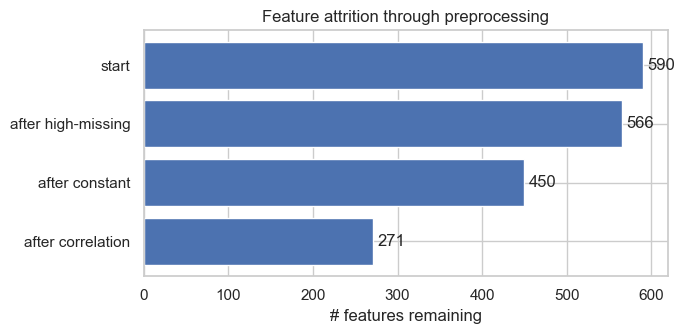

In [8]:
steps = {
    "start":            590,
    "after high-missing": 590 - len(dropped_missing),
    "after constant":     590 - len(dropped_missing) - len(dropped_const),
    "after correlation":  X_train_sc.shape[1],
}
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(list(steps.keys())[::-1], list(steps.values())[::-1], color="#4c72b0")
for i, v in enumerate(list(steps.values())[::-1]):
    ax.text(v + 5, i, str(v), va="center")
ax.set_xlabel("# features remaining")
ax.set_title("Feature attrition through preprocessing")
plt.tight_layout(); plt.show()

## Step 6 — SMOTE on the training set

Class weights are usually a cleaner imbalance fix than synthetic oversampling, but I want both options available to the modeling notebook. I'll save a SMOTE-balanced training set alongside the original imbalanced one. SMOTE is fit on the **training set only** — never on test.

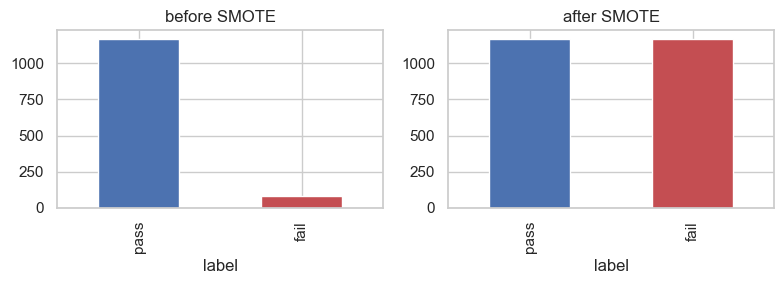

original train: {'pass': np.int64(1170), 'fail': np.int64(83)}
smote train   : {'pass': np.int64(1170), 'fail': np.int64(1170)}


In [9]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)

before = y_train.value_counts().rename({0: "pass", 1: "fail"})
after  = pd.Series(y_train_smote).value_counts().rename({0: "pass", 1: "fail"})

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
before.plot(kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"], title="before SMOTE")
after.plot(kind="bar", ax=axes[1], color=["#4c72b0", "#c44e52"], title="after SMOTE")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout(); plt.show()

print("original train:", dict(before))
print("smote train   :", dict(after))

## Cache everything to disk

Notebook 03 picks up from here without re-running any of this work.

In [10]:
out_dir = "../data/processed"
os.makedirs(out_dir, exist_ok=True)

np.savez_compressed(
    f"{out_dir}/secom_clean.npz",
    X_train=X_train_sc.values, y_train=y_train.values,
    X_test=X_test_sc.values,   y_test=y_test.values,
    X_train_smote=X_train_smote.values, y_train_smote=np.asarray(y_train_smote),
    feature_names=np.array(X_train_sc.columns.tolist()),
)
print("saved", f"{out_dir}/secom_clean.npz")

saved ../data/processed/secom_clean.npz


### Notes I want to remember

- I deliberately did **not** do feature scaling on the test set with test-set statistics. Even when imputing and scaling, fit is on train; transform is on test. The whole project is meaningless otherwise.
- I considered KNN imputation — better in theory for high-dim sensor data, but with this many features and limited samples per failure class it's slow and not obviously beneficial.
- I'm saving both the imbalanced and SMOTE versions of train. The modeling notebook will compare. My prior is that class-weighted XGBoost will edge out SMOTE+XGBoost, but I want the data to tell me.